# A/B Testing and Pricing Strategy Analysis

**Author:** Saksham Garg  
**GitHub:** [@realsakshamgarg](https://github.com/realsakshamgarg)  
**Project:** E-Commerce A/B Test — Comparing Old and New Pricing/Landing Pages

This notebook analyzes whether the new landing/pricing page changes conversion rates.
It includes data cleaning, exploratory analysis, and statistical hypothesis tests.


## Step 1: Import Libraries and Load Data

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest, proportion_confint

df = pd.read_csv("data/ab_data.csv")
print(df.shape)
df.head()

(294478, 5)


,user_id,timestamp,group,landing_page,converted
0,851104,2017-01-21 22:11:48.556739,control,old_page,0
1,804228,2017-01-12 08:01:45.159739,control,old_page,0
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0
4,864975,2017-01-21 01:52:26.210827,control,old_page,1


In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 294478 entries, 0 to 294477
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype
---  ------        --------------   -----
 0   user_id       294478 non-null  int64
 1   timestamp     294478 non-null  str  
 2   group         294478 non-null  str  
 3   landing_page  294478 non-null  str  
 4   converted     294478 non-null  int64
dtypes: int64(2), str(3)
memory usage: 11.2 MB


## Step 2: Data Cleaning

Two common problems in this dataset:
1. **Mismatched rows:** control users who saw `new_page`, or treatment users who saw `old_page`.
2. **Duplicate users:** the same `user_id` appearing more than once.

Both must be removed so the groups are valid.

In [20]:
mismatch = df[((df.group == "control") & (df.landing_page == "new_page")) |
              ((df.group == "treatment") & (df.landing_page == "old_page"))]
print("Mismatched rows:", len(mismatch))
df = df.drop(mismatch.index)

Mismatched rows: 3893


In [21]:
summary = df.groupby("group")["converted"].agg(["count", "sum", "mean"])
summary.columns = ["users", "conversions", "conv_rate"]
print(summary)

            users  conversions  conv_rate
group                                    
control    145274        17489   0.120386
treatment  145311        17264   0.118807


In [22]:
print("Duplicate users:", df.user_id.duplicated().sum())
df = df.drop_duplicates(subset="user_id", keep="first")
print("Rows after cleaning:", len(df))
print(df.isnull().sum())

Duplicate users: 1
Rows after cleaning: 290584
user_id         0
timestamp       0
group           0
landing_page    0
converted       0
dtype: int64


## Step 3: Exploratory Analysis

Compare the number of users, conversions, and conversion rate for each group.

In [23]:
summary = df.groupby("group")["converted"].agg(["count", "sum", "mean"])
summary.columns = ["users", "conversions", "conv_rate"]
summary

,users,conversions,conv_rate
group,,,
control,145274,17489,0.120386
treatment,145310,17264,0.118808


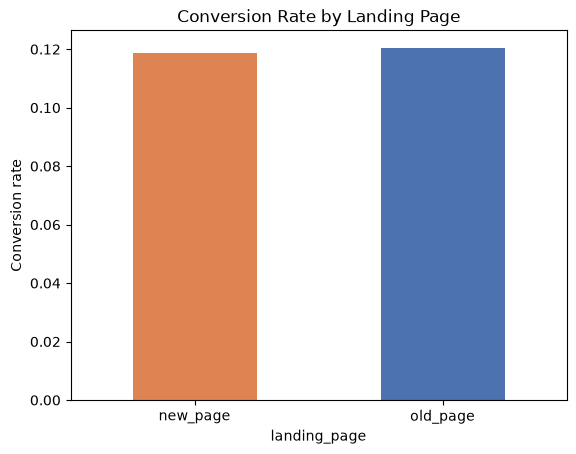

In [24]:
rates = df.groupby("landing_page")["converted"].mean()
rates.plot(kind="bar", color=["#DD8452", "#4C72B0"])
plt.ylabel("Conversion rate")
plt.title("Conversion Rate by Landing Page")
plt.xticks(rotation=0)
plt.show()

## Step 4: Hypotheses

- **H0 (null):** The conversion rate of the new page equals that of the old page.
- **H1 (alternative):** The conversion rates are different.
- **Significance level:** α = 0.05

## Step 5: A/B Test (Two-Proportion Z-Test)

We compare two proportions (conversion rates) from two independent groups.
- If **p-value < 0.05**, reject H0.
- If **p-value ≥ 0.05**, fail to reject H0.

In [25]:
control = df[df.group == "control"]["converted"]
treatment = df[df.group == "treatment"]["converted"]

count = np.array([treatment.sum(), control.sum()])
nobs = np.array([len(treatment), len(control)])

z_stat, p_value = proportions_ztest(count, nobs)
print(f"Z-statistic: {z_stat:.4f}")
print(f"P-value:     {p_value:.4f}")

if p_value < 0.05:
    print("Reject H0: significant difference between pages")
else:
    print("Fail to reject H0: no significant difference between pages")

Z-statistic: -1.3109
P-value:     0.1899
Fail to reject H0: no significant difference between pages


In [26]:
ci_t = proportion_confint(count[0], nobs[0], alpha=0.05)
ci_c = proportion_confint(count[1], nobs[1], alpha=0.05)
print("Treatment (new page) 95% CI:", ci_t)
print("Control (old page) 95% CI:  ", ci_c)

Treatment (new page) 95% CI: (0.11714442856134422, 0.12047170246886707)
Control (old page) 95% CI:   (0.11871294722381814, 0.12205966177710426)


## Step 6: Chi-Square Test of Independence

This test checks whether `converted` is **independent** of `landing_page`.

- **H0:** Conversion is independent of the landing page.
- **H1:** Conversion depends on the landing page.

**Assumption:** All expected frequencies should be at least 5.

In [27]:
contingency = pd.crosstab(df["landing_page"], df["converted"])
contingency

converted,0,1
landing_page,,
new_page,128046,17264
old_page,127785,17489


In [28]:
chi2, p, dof, expected = stats.chi2_contingency(contingency)

print(f"Chi-square statistic: {chi2:.4f}")
print(f"P-value:              {p:.4f}")
print(f"Degrees of freedom:   {dof}")
print("\nExpected frequencies:")
print(pd.DataFrame(expected, index=contingency.index, columns=contingency.columns))

if p < 0.05:
    print("\nReject H0: conversion depends on landing page")
else:
    print("\nFail to reject H0: conversion is independent of landing page")

Chi-square statistic: 1.7036
P-value:              0.1918
Degrees of freedom:   1

Expected frequencies:
converted                 0             1
landing_page                             
new_page      127931.347252  17378.652748
old_page      127899.652748  17374.347252

Fail to reject H0: conversion is independent of landing page


**Note:** `chi2_contingency` applies Yates' continuity correction by default for 2x2 tables. To turn it off, use `stats.chi2_contingency(contingency, correction=False)`.

## Step 7: Sanity Check

For a 2x2 table, the chi-square test and the two-proportion z-test are mathematically equivalent (χ² ≈ z²), so both should give nearly the same p-value.

In [29]:
chi2_nc, p_nc, _, _ = stats.chi2_contingency(contingency, correction=False)
print("z squared:             ", round(z_stat**2, 4))
print("Chi-square (no corr.): ", round(chi2_nc, 4))

z squared:              1.7185
Chi-square (no corr.):  1.7185


## Conclusion: A/B Test and Chi-Square Test

- After cleaning, 290,584 users were analyzed: 145,274 in control (old page) and 145,310 in treatment (new page).
- Conversion rate was **12.04%** for the old page and **11.88%** for the new page.
- Z-test: z = -1.3109, p = **0.1899**. Chi-square test: χ² = 1.7036, df = 1, p = **0.1918**.
- Since both p-values are greater than 0.05, we **fail to reject H0**. There is no significant difference between the pages, and conversion is independent of the landing page.
- **Recommendation:** The new page does not improve conversion, so keep the old page or redesign and retest.

# ANOVA on Landing Page A/B Test Data

**Goal:** Check whether conversion rate differs across **countries**, and whether the effect of the landing page depends on country.

**Datasets:**
- `ab_data.csv`: user_id, timestamp, group, landing_page, converted
- `countries.csv`: user_id, country

**Methods:** One-way ANOVA, Tukey HSD post-hoc test, Two-way ANOVA

    ## Step 1: Import Libraries and Load Data

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd

ab = pd.read_csv("data/ab_data.csv")
countries = pd.read_csv("data/countries.csv")

print(ab.shape, countries.shape)
countries.head()

(294478, 5) (290584, 2)


,user_id,country
0,834778,UK
1,928468,US
2,822059,UK
3,711597,UK
4,710616,UK


## Step 2: Clean the A/B Data

Remove mismatched rows (control seeing new page, treatment seeing old page) and duplicate users.

In [31]:
mismatch = ab[((ab.group == "control") & (ab.landing_page == "new_page")) |
              ((ab.group == "treatment") & (ab.landing_page == "old_page"))]
ab = ab.drop(mismatch.index)
ab = ab.drop_duplicates(subset="user_id", keep="first")
countries = countries.drop_duplicates(subset="user_id", keep="first")

print("Clean A/B rows:", len(ab))

Clean A/B rows: 290584


## Step 3: Merge the Datasets

Join on `user_id` so each user has a country attached.

In [32]:
df = ab.merge(countries, on="user_id", how="inner")
print(df.shape)
print(df.isnull().sum())
df.head()

(290584, 6)
user_id         0
timestamp       0
group           0
landing_page    0
converted       0
country         0
dtype: int64


,user_id,timestamp,group,landing_page,converted,country
0,851104,2017-01-21 22:11:48.556739,control,old_page,0,US
1,804228,2017-01-12 08:01:45.159739,control,old_page,0,US
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0,US
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0,US
4,864975,2017-01-21 01:52:26.210827,control,old_page,1,US


## Step 4: Explore Conversion by Country    

In [33]:
summary = df.groupby("country")["converted"].agg(["count", "sum", "mean", "std"])
summary.columns = ["users", "conversions", "conv_rate", "std"]
summary

,users,conversions,conv_rate,std
country,,,,
CA,14499,1672,0.115318,0.319417
UK,72466,8739,0.120594,0.325658
US,203619,24342,0.119547,0.324432


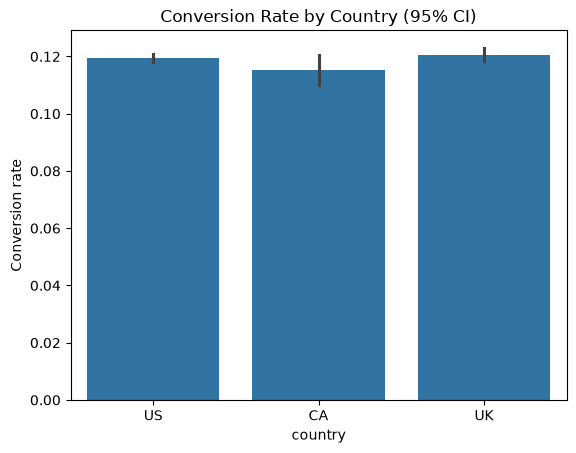

In [34]:
sns.barplot(data=df, x="country", y="converted", errorbar=("ci", 95))
plt.ylabel("Conversion rate")
plt.title("Conversion Rate by Country (95% CI)")
plt.show()

## Step 5: Hypotheses (One-Way ANOVA)

- **H0:** Mean conversion rate is the same across all countries.
- **H1:** At least one country has a different mean conversion rate.
- **Significance level:** α = 0.05

## Step 6: Check ANOVA Assumptions

1. **Independence:** each user appears once (ensured by removing duplicates).
2. **Equal variances:** checked with Levene's test.
3. **Normality:** `converted` is binary, so it is not normal. With very large samples the ANOVA F-test is still robust (Central Limit Theorem), so we treat this as acceptable here.

**Levene's test:** H0 = variances are equal across groups.

In [35]:
groups = [g["converted"].values for _, g in df.groupby("country")]

lev_stat, lev_p = stats.levene(*groups)
print(f"Levene statistic: {lev_stat:.4f}")
print(f"P-value:          {lev_p:.4f}")

Levene statistic: 1.6053
P-value:          0.2008


## Step 7: One-Way ANOVA

- If **p < 0.05**, reject H0 and run a post-hoc test.
- If **p ≥ 0.05**, fail to reject H0.

## Step 7: One-Way ANOVA

- If **p < 0.05**, reject H0 and run a post-hoc test.
- If **p ≥ 0.05**, fail to reject H0.

In [36]:
f_stat, p_value = stats.f_oneway(*groups)
print(f"F-statistic: {f_stat:.4f}")
print(f"P-value:     {p_value:.4f}")

if p_value < 0.05:
    print("Reject H0: conversion differs across countries")
else:
    print("Fail to reject H0: no significant difference across countries")

F-statistic: 1.6053
P-value:     0.2008
Fail to reject H0: no significant difference across countries


In [37]:
# Full ANOVA table using statsmodels
model = ols("converted ~ C(country)", data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
anova_table

,sum_sq,df,F,PR(>F)
C(country),0.338053,2.0,1.605286,0.200834
Residual,30596.304374,290581.0,NaN,NaN


## Step 8: Post-Hoc Test (Tukey HSD)

ANOVA only says that *some* difference exists. Tukey HSD shows **which country pairs** differ. Only needed if the ANOVA p-value is below 0.05, but running it is harmless.

In [38]:
tukey = pairwise_tukeyhsd(endog=df["converted"], groups=df["country"], alpha=0.05)
print(tukey)

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
    CA     UK   0.0053 0.1738 -0.0016 0.0122  False
    CA     US   0.0042 0.2833 -0.0023 0.0108  False
    UK     US   -0.001 0.7358 -0.0043 0.0022  False
---------------------------------------------------


## Step 9: Cross-Check with Chi-Square

Because the outcome is binary, a chi-square test of independence between `country` and `converted` is a natural cross-check. It should agree with the ANOVA conclusion.

In [39]:
ct = pd.crosstab(df["country"], df["converted"])
chi2, p, dof, expected = stats.chi2_contingency(ct)
print(ct)
print(f"\nChi-square: {chi2:.4f}, p-value: {p:.4f}, dof: {dof}")

converted       0      1
country                 
CA          12827   1672
UK          63727   8739
US         179277  24342

Chi-square: 3.2106, p-value: 0.2008, dof: 2


## Step 10: Two-Way ANOVA (Landing Page × Country)

Now test both factors together:
- **Main effect of landing page:** does the page matter?
- **Main effect of country:** does the country matter?
- **Interaction:** does the page's effect differ by country?

Hypotheses for the interaction: H0 = no interaction, H1 = interaction exists.

In [40]:
model2 = ols("converted ~ C(landing_page) * C(country)", data=df).fit()
anova2 = sm.stats.anova_lm(model2, typ=2)
anova2

,sum_sq,df,F,PR(>F)
C(landing_page),0.179842,1.0,1.708013,0.191244
C(country),0.336945,2.0,1.600034,0.201891
C(landing_page):C(country),0.254135,2.0,1.206796,0.299156
Residual,30595.870398,290578.0,NaN,NaN


In [41]:
# Conversion rate for each page-country combination
pivot = df.pivot_table(values="converted", index="country",
                       columns="landing_page", aggfunc="mean")
pivot

landing_page,new_page,old_page
country,,
CA,0.111902,0.118783
UK,0.121171,0.120022
US,0.118466,0.120630


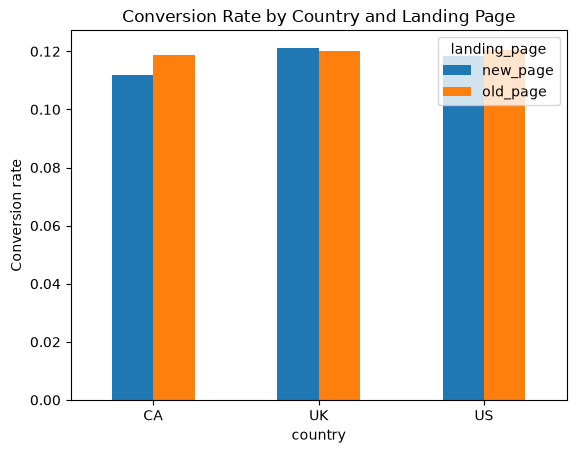

In [42]:
pivot.plot(kind="bar")
plt.ylabel("Conversion rate")
plt.title("Conversion Rate by Country and Landing Page")
plt.xticks(rotation=0)
plt.show()

## Conclusion: ANOVA

- Conversion rates by country: CA **11.53%**, UK **12.06%**, US **11.95%**.
- One-way ANOVA: F = 1.6053, p = **0.2008**. Levene's test (p = 0.2008) confirms equal variances.
- Tukey HSD shows no significant difference between any pair of countries (all adjusted p > 0.17).
- Two-way ANOVA: landing page (p = 0.1912), country (p = 0.2019), and their interaction (p = 0.2992) are all not significant.
- Since all p-values are greater than 0.05, we **fail to reject H0**. Neither the landing page nor the country significantly affects conversion, and the page's effect does not vary by country.
- **Recommendation:** There is no evidence to replace the old page in any country.